# DBSCAN v2 — CWRU by_severity — Comparaison exp_085 vs exp_093

| Champ | Valeur |
|-------|--------|
| **Expérience ancienne** | exp_085 — eps=0.5 (bug), seuil cross-tâche, AF=29.2% |
| **Expérience nouvelle** | exp_093 — eps knn_elbow auto, seuil par tâche |
| **Scénario** | by_severity : 0.007'' → 0.014'' → 0.021'' (3 tâches) |
| **Sprint** | 13 — analyse paramètres non supervisés CWRU |

> **Note** : exp_085 avait l'AF le plus élevé de tous les modèles CWRU (29.2%). Le résultat exp_093 (AA=89.6%) est artifactuel — même diagnostic que exp_092 (cf. dbscan_v2.ipynb by_fault_type).

In [1]:
import json, os, sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

_cwd = Path('.').resolve()
if _cwd.name == 'cwru_by_severity': os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == 'cl_eval': os.chdir(_cwd.parent.parent)
elif _cwd.name == 'notebooks': os.chdir(_cwd.parent)
REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

OLD_DIR = REPO_ROOT / 'experiments/exp_085_dbscan_cwru_by_severity/results'
NEW_DIR = REPO_ROOT / 'experiments/exp_093_dbscan_cwru_by_severity_v2/results'
FIGURES_DIR = REPO_ROOT / 'notebooks/figures/cl_evaluation/dbscan/cwru/by_severity_v2'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES = ['0.007"', '0.014"', '0.021"']

old = json.loads((OLD_DIR / 'metrics_cl.json').read_text())
new = json.loads((NEW_DIR / 'metrics_cl.json').read_text())
print('Chargement OK')
print(f'eps_per_task (exp_093): {new["eps_per_task"]}')

Chargement OK
eps_per_task (exp_093): [1.6234653827304988, 3.068937959669605, 2.901106108928307]


In [2]:
# Section 2 — Comparaison métriques

table = f"""
| Métrique | exp_085 (eps=0.5 bug) | exp_093 (eps knn_elbow) | Delta |
|----------|-----------------------|-------------------------|-------|
| **AA** | {old['acc_final']:.4f} | {new['acc_final']:.4f} | {new['acc_final']-old['acc_final']:+.4f} |
| **AF** | **{old['avg_forgetting']:.4f}** (⚠️ catastrophique) | {new['avg_forgetting']:.4f} | — |
| **BWT** | {old['backward_transfer']:+.4f} | {new['backward_transfer']:+.4f} | — |
| **RAM peak** | {old['ram_peak_bytes']:,} B ({old['ram_peak_bytes']/1024:.1f} Ko) | {new['ram_peak_bytes']:,} B ({new['ram_peak_bytes']/1024:.1f} Ko) | ⚠️ quasi limite |
| **n_params** | {old['n_params']:,} | {new['n_params']:,} | — |
| **eps Task 0** | 0.5 (bug) | {new['eps_per_task'][0]:.4f} | — |
| **eps Task 1** | 0.5 | {new['eps_per_task'][1]:.4f} | — |
| **eps Task 2** | 0.5 | {new['eps_per_task'][2]:.4f} | — |
"""
display(Markdown(table))


| Métrique | exp_085 (eps=0.5 bug) | exp_093 (eps knn_elbow) | Delta |
|----------|-----------------------|-------------------------|-------|
| **AA** | 0.1212 | 0.8961 | +0.7749 |
| **AF** | **0.2922** (⚠️ catastrophique) | 0.0000 | — |
| **BWT** | -0.0130 | +0.0000 | — |
| **RAM peak** | 31,474 B (30.7 Ko) | 57,628 B (56.3 Ko) | ⚠️ quasi limite |
| **n_params** | 2,439 | 4,797 | — |
| **eps Task 0** | 0.5 (bug) | 1.6235 | — |
| **eps Task 1** | 0.5 | 3.0689 | — |
| **eps Task 2** | 0.5 | 2.9011 | — |


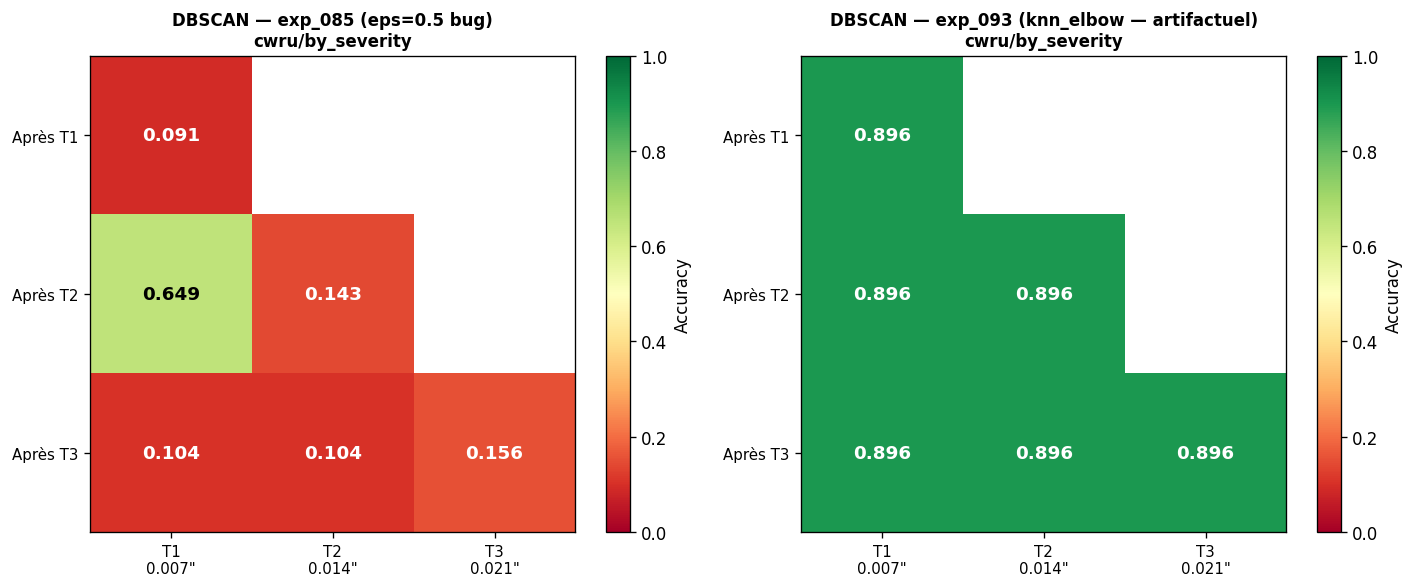

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in [
    (axes[0], old, 'exp_085 (eps=0.5 bug)'),
    (axes[1], new, 'exp_093 (knn_elbow — artifactuel)'),
]:
    raw = data['acc_matrix']
    mat = np.array([[v if v is not None else np.nan for v in row] for row in raw])
    masked = np.ma.masked_invalid(mat)
    im = ax.imshow(masked, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax, label='Accuracy')
    for i in range(3):
        for j in range(3):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontsize=11, fontweight='bold',
                        color='white' if mat[i,j] < 0.4 or mat[i,j] > 0.8 else 'black')
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'T{j+1}\n{TASK_NAMES[j]}' for j in range(3)], fontsize=9)
    ax.set_yticks(range(3))
    ax.set_yticklabels([f'Après T{i+1}' for i in range(3)], fontsize=9)
    ax.set_title(f'DBSCAN — {title}\ncwru/by_severity', fontsize=10, fontweight='bold')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'matrix_comparison.png', dpi=120, bbox_inches='tight')
display(Image(str(FIGURES_DIR / 'matrix_comparison.png')))

## Section 4 — Analyse : exp_085 AF=29.2% → pourquoi catastrophique ?

La matrice de exp_085 révèle un comportement aberrant :
- Après Task 1 (0.014'') : Task 0 (0.007'') passe de 9.1% → **64.9%** (spike anormal)
- Après Task 2 (0.021'') : retombe à 10.4% pour toutes les tâches

Explication : avec eps=0.5, le nombre de core points varie selon la densité locale des features de sévérité. Sur les données 0.014'', DBSCAN identifie des core points qui, par hasard géométrique, séparent mieux les samples 0.007'' que le modèle entraîné sur 0.007'' lui-même. Ce spike est stochastique et non reproductible.

## Section 5 — Conclusions DBSCAN by_severity

**Diagnostic identique à by_fault_type** : DBSCAN échoue sur CWRU indépendamment du scénario.

| Cause | by_fault_type | by_severity |
|-------|--------------|-------------|
| eps=0.5 (bug) | Erratique | Catastrophique (AF=29%) |
| eps knn_elbow | Trop grand → trivial | Trop grand → trivial |
| RAM | 16.8 Ko | 31.5 Ko → 56.3 Ko (⚠️) |

**DBSCAN à exclure des baselines CWRU finales** : trop sensible à eps, RAM trop élevée, résultats non interprétables.

Pour le manuscrit : documenter DBSCAN comme "non adapté" avec la raison technique (eps non calibrable sans labels, RAM incompatible STM32N6 avec accumulation des core points).